In [ ]:
%pip install puremacro


# Transmisión dependiente del estado, bien hecha

**¿Cómo varía la transmisión macroeconómica de los choques estructurales entre regímenes, como condiciones financieras de calma y de estrés?** Los modelos de regímenes — VAR de umbral, VAR con cambio de
régimen markoviano, VECM de umbral — existen exactamente para responder
eso. Pero ajustar uno y luego empujar sus coeficientes por régimen a
través de una rutina de IRF *lineal* responde en silencio una pregunta
distinta: "¿qué pasaría si la economía estuviera encerrada en ese régimen
para siempre?" Durante mucho tiempo ese atajo de régimen congelado era la
única respuesta al impulso que los ajustes de regímenes de este paquete
podían ofrecer. Este notebook construye el objeto correcto — la **IRF
generalizada** de Koop, Pesaran y Potter (1996, *J. Econometrics*) — y la
usa para recuperar una asimetría plantada, contrastarla con una banda
bootstrap y exponer la no linealidad en tamaño/signo al estilo de Kilian
y Vigfusson (2011).

## El método en matemáticas: de la IRF lineal a la IRF generalizada

Un VAR de umbral con dos regímenes cambia su dinámica según una variable
de umbral rezagada $z_{t-d}$:
$$ y_t = c^{(r_t)} + A^{(r_t)} y_{t-1} + \varepsilon_t^{(r_t)}, \qquad
   r_t = \mathbb{1}\{z_{t-d} > c\}. $$
En un VAR lineal la IRF es una única trayectoria determinista. Aquí la
respuesta depende de la **historia** $\omega_{t-1}$ (en qué régimen
empiezas) y del **tamaño y signo** del choque (un choque grande puede
empujar a $z$ a cruzar el umbral en pleno vuelo), así que KPP definen la
IRF como una esperanza condicional e integran el futuro por Monte Carlo:
$$ GI(h, \delta, \omega_{t-1}) =
   \mathbb{E}\!\left[y_{t+h} \mid \varepsilon_{j,t}+\delta,\ \omega_{t-1}\right]
 - \mathbb{E}\!\left[y_{t+h} \mid \omega_{t-1}\right]. $$
El estimador simula **trayectorias emparejadas**: una base con
innovaciones $\varepsilon \sim N(0, I)$ mapeadas a través del factor de
Cholesky del *régimen vigente*, y una gemela con choque que suma $\delta$
al choque identificado $j$ en $h=0$ — mismos sorteos en todo lo demás. A
lo largo de ambas trayectorias el régimen se reevalúa con la $z$ simulada
en cada paso: **el cambio de régimen es endógeno**. Promediando sobre
historias extraídas de la muestra, condicionales al régimen inicial, se
obtienen $GI_{\text{calma}}(h)$, $GI_{\text{estrés}}(h)$ y el estadístico
de asimetría de transmisión
$$ \Delta(h) = GI_{\text{estrés}}(h) - GI_{\text{calma}}(h), $$
con banda por bootstrap sobre las historias extraídas. El chequeo de
Kilian-Vigfusson completa el instrumental: en un modelo lineal
$GI(2\delta) = 2\,GI(\delta)$ y $GI(-\delta) = -GI(\delta)$, así que
graficar $GI(\delta)/\delta$ entre tamaños y signos mide cuán no lineal
es realmente la transmisión.

### Parámetros de la simulación base

| Símbolo | Descripción del parámetro | Valor base | Unidades / Convención contable |
| :--- | :--- | :--- | :--- |
| $c^*$ | Parámetro de umbral verdadero que separa los regímenes | $0.00$ | Unidades del ICF simulado (innovación con desviación estándar 1) |
| $d$ | Parámetro de retardo del umbral | $1$ | Período de rezago ($z_{t-1}$) |
| $T$ | Longitud total de la simulación | $600$ | Trimestres ($150$ años) |
| $R$ | Trayectorias emparejadas de Monte Carlo por historia (GIRF principal) | $80$ | Trayectorias por historia; $40$ historias por régimen inicial |
| $A_{\text{calma}}$ | Matriz autorregresiva en régimen de calma | $[[0.5, 0], [-0.1, 0.4]]$ | Parámetros de transición de estado |
| $A_{\text{estrés}}$ | Matriz autorregresiva en régimen de estrés | $[[0.8, 0], [-0.5, 0.4]]$ | Persistencia elevada y mayor arrastre |

**Intuición.** Una IRF lineal es un solo número por horizonte porque un
modelo lineal trata idénticamente cada trimestre y cada tamaño de choque.
Un modelo de regímenes no: la transmisión depende de dónde *está* la
economía — y, crucialmente, de adónde la *envía* el choque. Si un choque
de estrés financiero arrastra a la economía a cruzar el umbral, el choque
cambia la propia dinámica a través de la cual se propagará; congelar el
régimen supone eliminar exactamente esa retroalimentación. La GIRF la
conserva: las historias vienen de la muestra (así que "empezar en
estrés" significa los trimestres de estrés que los datos realmente
contienen), las trayectorias cambian de régimen endógenamente, y la IRF
se convierte en un *promedio de futuros* en lugar de una recursión
mecánica. El precio es ruido de simulación; la recompensa es un objeto
que puede diferir honestamente entre regímenes, tamaños y signos — y una
banda de diferencias que te dice si lo hace.

### Referencias clave

- **Koop, G., Pesaran, M. H., & Potter, S. M. (1996).** *Impulse response analysis in nonlinear multivariate models.* Journal of Econometrics, 74(1), 119–147.
- **Kilian, L., & Vigfusson, R. J. (2011).** *Are the responses of the U.S. economy asymmetric in energy price increases and decreases?* Quantitative Economics, 2(3), 419–453.
- **Tsay, R. S. (1998).** *Testing and modeling multivariate threshold models.* Journal of the American Statistical Association, 93(443), 1188–1202.
- **Hansen, B. E. (1999).** *Threshold effects in non-dynamic panels: Estimation, testing, and inference.* Journal of Econometrics, 93(2), 345–368.
- **Krolzig, H.-M. (1997).** *Markov-Switching Vector Autoregressions.* Lecture Notes in Economics and Mathematical Systems. Springer. doi:10.1007/978-3-642-51684-9
- **Caldara, D., Fuentes-Albero, C., Gilchrist, S., & Zakrajšek, E. (2016).** *The macroeconomic impact of financial and uncertainty shocks.* European Economic Review, 88, 185–207.

## Preparación — una economía simulada con regímenes de calma y estrés

Dos variables: un índice de condiciones financieras ($z_t$, columna 0 —
la variable de umbral) y el crecimiento del producto (columna 1).
**Plantamos** la dependencia del estado: en el régimen de estrés
($z_{t-1} > 0$) el ICF es más persistente (0.8 vs 0.5) y arrastra al
crecimiento cinco veces más fuerte (−0.5 vs −0.1). La covarianza de las
innovaciones es la *identidad en ambos regímenes*, de modo que toda
asimetría de aquí en adelante es transmisión, no volatilidad de impacto.

T = 600 quarters | share of stress quarters = 0.588


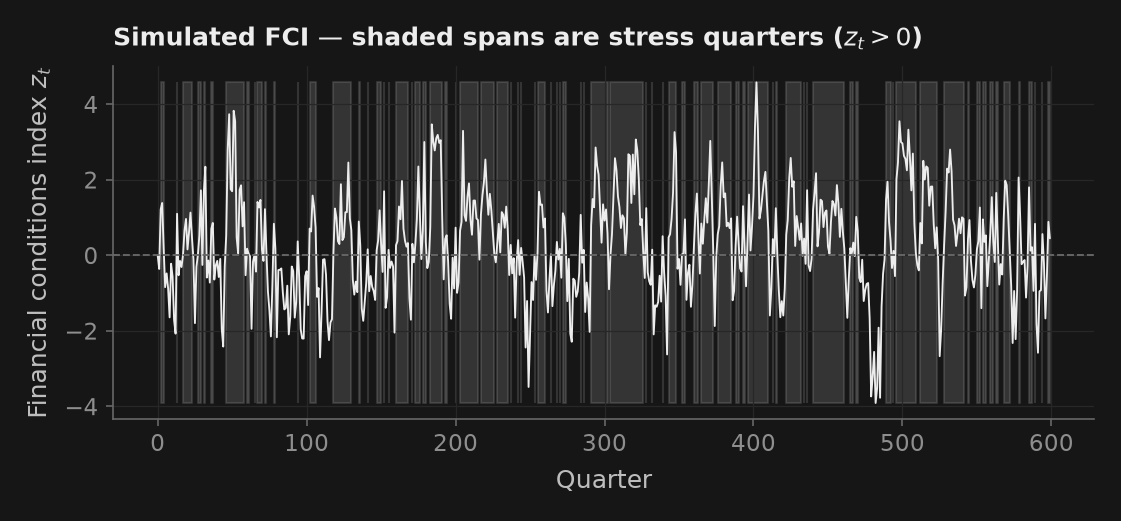

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.var.estimate import estimate_var
from puremacro.var.irf import irf as var_irf
from puremacro.var.regime import girf, tvar_fit
from puremacro.var.regime.threshold import TVARResult

A_CALM = np.array([[0.5, 0.0],      # FCI moderately persistent
                   [-0.1, 0.4]])    # ...and a mild drag on growth
A_STRESS = np.array([[0.8, 0.0],    # FCI very persistent under stress
                     [-0.5, 0.4]])  # ...and a 5x stronger drag on growth

def simulate_economy(T=600, seed=20):
    """Self-exciting TVAR(1): regime decided by last quarter's FCI."""
    rng = np.random.default_rng(seed)
    Y = np.zeros((T, 2))
    for t in range(1, T):
        A = A_STRESS if Y[t - 1, 0] > 0.0 else A_CALM
        Y[t] = A @ Y[t - 1] + rng.standard_normal(2)
    return Y

Y = simulate_economy()
stress_share = float((Y[:, 0] > 0.0).mean())
print(f"T = {len(Y)} quarters | share of stress quarters = {stress_share:.3f}")
assert 0.40 < stress_share < 0.70   # both regimes well populated

fig, ax = _nbstyle.figura(ancho=7.2, alto=3.2)
ax.plot(Y[:, 0], color=_nbstyle.TINTA, linewidth=0.9)
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.9, linestyle="--")
ax.fill_between(np.arange(len(Y)), Y[:, 0].min(), Y[:, 0].max(),
                where=Y[:, 0] > 0.0, color=_nbstyle.NOTA, alpha=0.25, zorder=0)
ax.set_xlabel("Quarter")
ax.set_ylabel("Financial conditions index $z_t$")
ax.set_title("Simulated FCI — shaded spans are stress quarters ($z_t > 0$)")

## Ajustar el VAR de umbral

`tvar_fit` busca en una malla el umbral $c$ y el rezago de decisión $d$
(Tsay 1998) y corre OLS por régimen. Nada le dice que la partición
verdadera está en cero — tiene que encontrar eso, y la brecha de
coeficientes plantada, por su cuenta. Un detalle: `tvar_fit` solo prueba
rezagos $d \le p$ y descarta los demás sin avisar, así que con el orden
de rezagos verdadero $p=1$ el rezago queda fijo en 1 y no se puede
"encontrar". Usamos el ajuste con $p=1$ en el resto del notebook y
corremos la búsqueda del rezago como un chequeo aparte con $p=2$, donde
$d=2$ es un candidato real. Un segundo chequeo es independiente de
`puremacro`: MCO simple sobre la partición *verdadera* ($z_{t-1} > 0$),
que dice cuánto de cualquier error de estimación es ruido muestral en
esta única muestra y no efecto del umbral estimado.

In [2]:
fit = tvar_fit(Y, threshold_var_idx=0, p=1, delay_grid=(1,), n_threshold_grid=40)
print(f"threshold c = {fit.threshold:+.3f} (true 0.0) | delay d = {fit.delay} (only d <= p = 1 is tried)")
print(f"regime split: {fit.n_low} calm / {fit.n_high} stress quarters")
print("A_low  (calm)  =", np.round(fit.A_low, 3).tolist())
print("A_high (stress)=", np.round(fit.A_high, 3).tolist())

# a delay search that can fail: at p = 2 both d = 1 and d = 2 are admissible
fit_p2 = tvar_fit(Y, threshold_var_idx=0, p=2, delay_grid=(1, 2), n_threshold_grid=40)
print(f"delay search at p = 2 over d in (1, 2): d = {fit_p2.delay} (true 1)")

# independent check: OLS with intercept on the true stress quarters (z_{t-1} > 0)
X_true = np.column_stack([np.ones(len(Y) - 1), Y[:-1]])
in_stress = Y[:-1, 0] > 0.0
B_true = np.linalg.lstsq(X_true[in_stress], Y[1:][in_stress], rcond=None)[0]
print(f"OLS on the true split: stress FCI persistence = {B_true[1, 0]:.3f}, "
      f"growth drag = {B_true[1, 1]:.3f} (true 0.8 and -0.5)")
assert fit_p2.delay == 1                              # the true delay wins when d = 2 is allowed
assert abs(fit.threshold) < 0.5                       # near the true zero
assert fit.A_high[1, 0] < fit.A_low[1, 0] - 0.25      # planted cross-effect gap

threshold c = +0.236 (true 0.0) | delay d = 1 (only d <= p = 1 is tried)
regime split: 294 calm / 305 stress quarters
A_low  (calm)  = [[0.526, -0.089], [-0.11, 0.356]]
A_high (stress)= [[0.691, 0.008], [-0.472, 0.419]]
delay search at p = 2 over d in (1, 2): d = 1 (true 1)
OLS on the true split: stress FCI persistence = 0.744, growth drag = -0.419 (true 0.8 and -0.5)


**Lectura de los resultados.** El umbral cae en $+0.236$ (verdadero 0) y,
cuando un segundo rezago es admisible ($p=2$), la búsqueda elige $d=1$,
el rezago verdadero. El régimen de estrés estimado lleva las dos huellas
plantadas: persistencia del ICF de 0.691 frente a 0.526 en calma
(verdaderos 0.8 y 0.5), y un arrastre sobre el crecimiento de −0.472
frente a −0.11 (verdaderos −0.5 y −0.1). ¿Por qué 0.691 y no 0.8? Cerca
de la mitad de la brecha es ruido muestral en esta única muestra de 600
trimestres: MCO sobre la partición verdadera da 0.744. El resto viene del
umbral estimado. Con $c = +0.236$ el régimen de estrés conserva solo los
trimestres con $z_{t-1} > 0.236$, así que pierde trimestres de estrés
verdaderos en lugar de sumar trimestres de calma. Hasta aquí esto es solo
estimación; la pregunta es qué *significan* estos dos bloques de
coeficientes para un choque — y eso no se responde alimentando cualquiera
de los bloques a una IRF lineal.

## La GIRF: historias, cambio endógeno, simulación emparejada

Una sola llamada ejecuta la construcción KPP completa: extraer 40
historias por régimen inicial de la muestra, simular 80 trayectorias
emparejadas por historia con el impulso sumado al choque identificado del
ICF en $h=0$ (Cholesky dentro del régimen), dejar que el régimen cambie
endógenamente a lo largo de cada trayectoria, y promediar.
`shock_size=[1, 2, -1, -2]` añade el menú de tamaño/signo de
Kilian-Vigfusson, y la diferencia entre regímenes viene con una banda
bootstrap al 90%.

Regime GIRF (tvar)
  regimes           : 2 ('low', 'high')
  shock / sizes     : eq 0 / [1.0, 2.0, -1.0, -2.0]
  horizon           : 16
  histories x sims  : 40 x 80 per regime
  difference band   : 90% bootstrap, B = 300

growth response at h=2: calm -0.238 | stress -0.418 (ratio 1.75)
difference (stress-calm) at h=2: -0.179, 90% band [-0.199, -0.163]
band entirely below zero at 15 of 17 horizons: h = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
FCI's own response at h=1: calm +0.680 | stress +0.688
cumulative growth loss in stress: frozen-regime -2.56 vs GIRF -1.93


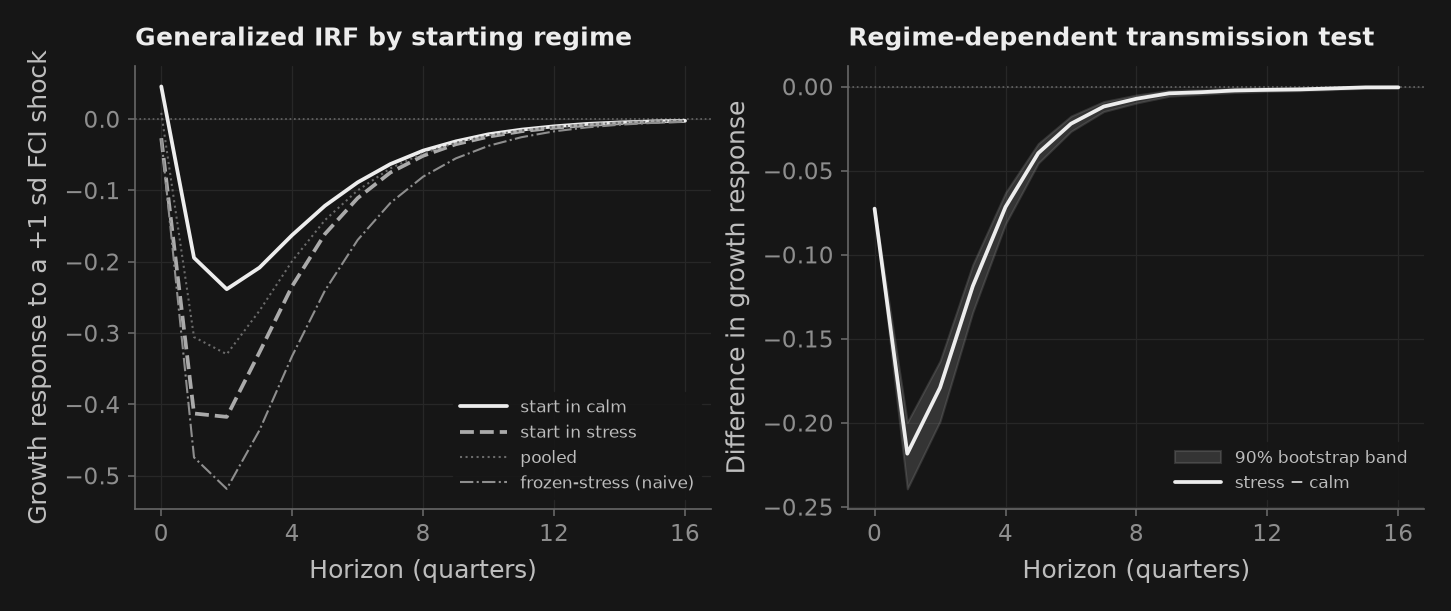

In [3]:
res = girf(fit, Y, shock=0, horizon=16, n_hist=40, n_sim=80,
           shock_size=[1.0, 2.0, -1.0, -2.0], n_boot=300, rng=16)
print(res.summary())

h = np.arange(res.horizon + 1)
g_calm = res.girf_by_regime[0, 0]     # (+1 sd shock) x (H+1, n)
g_strs = res.girf_by_regime[1, 0]
d_gr = res.difference[0, :, 1]
d_lo = res.difference_lo[0, :, 1]
d_hi = res.difference_hi[0, :, 1]
print(f"growth response at h=2: calm {g_calm[2, 1]:+.3f} | stress {g_strs[2, 1]:+.3f} "
      f"(ratio {g_strs[2, 1] / g_calm[2, 1]:.2f})")
print(f"difference (stress-calm) at h=2: {d_gr[2]:+.3f}, 90% band "
      f"[{d_lo[2]:+.3f}, {d_hi[2]:+.3f}]")
below = np.flatnonzero(d_hi < 0.0)
print(f"band entirely below zero at {below.size} of {h.size} horizons: h = {below.tolist()}")
print(f"FCI's own response at h=1: calm {g_calm[1, 0]:+.3f} | stress {g_strs[1, 0]:+.3f}")
assert g_strs[2, 1] < g_calm[2, 1] - 0.10   # stress transmission is stronger...
assert d_hi[2] < -0.10                      # ...and the band excludes zero

# the naive frozen-regime IRF: pretend the economy never leaves stress
naive = var_irf([fit.A_high], np.linalg.cholesky(fit.Sigma_high), 16)[:, :, 0]
cum_naive, cum_girf = naive[:, 1].sum(), g_strs[:, 1].sum()
print(f"cumulative growth loss in stress: frozen-regime {cum_naive:+.2f} "
      f"vs GIRF {cum_girf:+.2f}")
assert cum_naive < cum_girf - 0.30          # freezing the regime overstates it

cols2 = _nbstyle.palette(3)
fig, axes = _nbstyle.figura(ancho=9.4, alto=3.8, ncols=2)
axes[0].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
axes[0].plot(h, g_calm[:, 1], color=cols2[0], linewidth=1.8, label="start in calm")
axes[0].plot(h, g_strs[:, 1], color=cols2[1], linewidth=1.8, linestyle="--",
             label="start in stress")
axes[0].plot(h, res.girf_pooled[0, :, 1], color=cols2[2], linewidth=1.0,
             linestyle=":", label="pooled")
axes[0].plot(h, naive[:, 1], color=_nbstyle.NOTA, linewidth=1.0, linestyle="-.",
             label="frozen-stress (naive)")
axes[0].set_xlabel("Horizon (quarters)")
axes[0].set_ylabel("Growth response to a +1 sd FCI shock")
axes[0].set_title("Generalized IRF by starting regime")
axes[0].legend(fontsize=8)
axes[1].axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
axes[1].fill_between(h, d_lo, d_hi, color=_nbstyle.NOTA, alpha=0.25,
                     label="90% bootstrap band")
axes[1].plot(h, d_gr, color=_nbstyle.TINTA, linewidth=1.8, label="stress $-$ calm")
axes[1].set_xlabel("Horizon (quarters)")
axes[1].set_ylabel("Difference in growth response")
axes[1].set_title("Regime-dependent transmission test")
axes[1].legend(fontsize=8)
for a in axes:
    a.set_xticks(h[::4])

**Lectura de los resultados.** Panel izquierdo: el mismo choque financiero de +1
desviación estándar cuesta **−0.418** de crecimiento en $h=2$ cuando
aterriza en estrés frente a **−0.238** en calma — 1.75 veces el daño,
puramente por dónde aterriza. La línea ingenua de estrés congelado
sobrestima la respuesta de estrés (pérdida acumulada −2.56 frente a −1.93
de la GIRF): las trayectorias reales *escapan* al régimen de calma
conforme el ICF revierte a la media, y la GIRF promedia esas salidas
mientras que la recursión congelada las prohíbe. Panel derecho: la
diferencia estrés-menos-calma en $h=2$ es −0.179 con banda al 90% de
[−0.199, −0.163], y la banda queda enteramente por debajo de cero en los
horizontes 0 a 14. Eso recupera la asimetría que plantamos. Lee la banda
por lo que es: remuestrea historias y sorteos de simulación con los
coeficientes ajustados fijos, así que no lleva incertidumbre de
estimación y es más angosta de lo que sería un contraste completo de
transmisión dependiente del régimen (el ejercicio avanzado de abajo
muestra un caso en el que colapsa a una línea). Una sutileza que vale la
pena saborear: la respuesta *propia* del ICF en $h=1$ es +0.680 partiendo
de calma y +0.688 partiendo de estrés, mucho más cerca de lo que sugiere
la persistencia ajustada (0.526 frente a 0.691). Un choque positivo en
calma empuja al ICF a cruzar el umbral y entonces se propaga de todos
modos con la dinámica de estrés — el cambio endógeno en acción.

## Asimetría de tamaño y signo, al estilo Kilian-Vigfusson

En un modelo lineal $GI(\delta)/\delta$ es una sola curva, sea cual sea
$\delta$. En un modelo de umbral no: un choque de +2 desviaciones pasa
más parte de su vida en el régimen de estrés que uno de +1, y un choque
de −1 activamente *rescata* a la economía del estrés. Dividir cada GIRF
por su propio $\delta$ hace visibles esas desviaciones.

max size deviation |GI(2)/2 - GI(1)|  (growth): 0.045
max sign deviation |GI(-1)/-1 - GI(1)| (growth): 0.097
per-sd growth response at h=2: +1 sd -0.330 | +2 sd -0.375 | -1 sd -0.232 | -2 sd -0.195


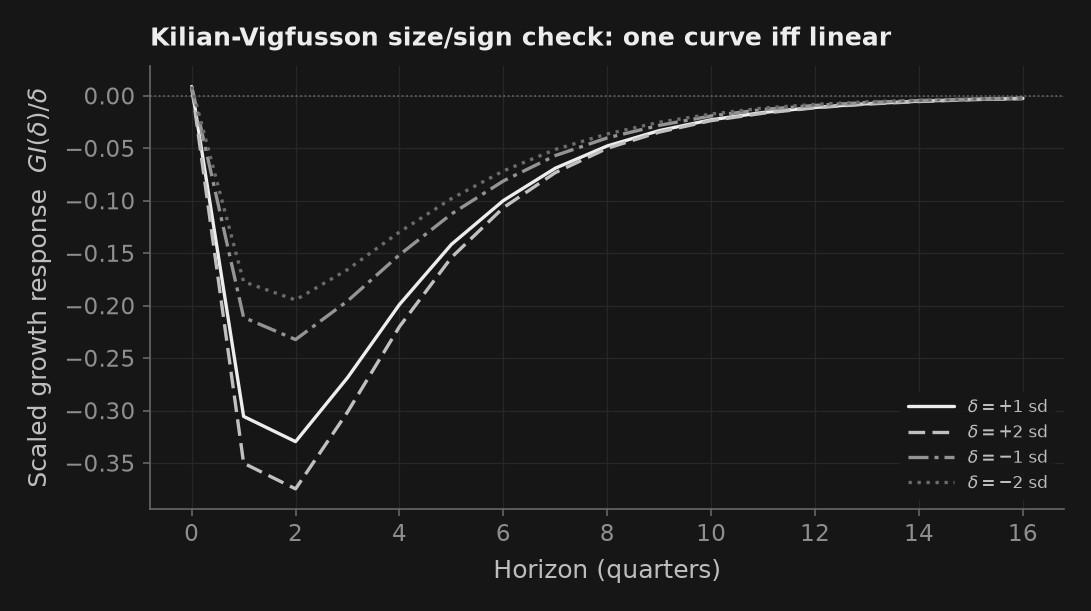

In [4]:
sc = res.scaled()                     # girf_pooled / delta, shape (S, H+1, n)
labels = [f"$\\delta = {d:+.0f}$ sd" for d in res.shock_sizes]
cols = _nbstyle.palette(4)
stys = _nbstyle.styles(4)
dev_size = np.abs(sc[1, :, 1] - sc[0, :, 1]).max()   # |GI(2d)/2 - GI(d)| gap
dev_sign = np.abs(sc[2, :, 1] - sc[0, :, 1]).max()   # |GI(-d)/(-d) - GI(d)| gap
print(f"max size deviation |GI(2)/2 - GI(1)|  (growth): {dev_size:.3f}")
print(f"max sign deviation |GI(-1)/-1 - GI(1)| (growth): {dev_sign:.3f}")
print("per-sd growth response at h=2: " + " | ".join(
    f"{d:+.0f} sd {sc[s, 2, 1]:+.3f}" for s, d in enumerate(res.shock_sizes)))
assert np.abs(sc[:, 0, :] - sc[0, 0, :]).max() < 1e-12  # impact IS proportional
assert dev_size > 0.02 and dev_sign > 0.05              # dynamics are NOT

fig, ax = _nbstyle.figura(ancho=7.0, alto=3.8)
ax.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
for s in range(4):
    ax.plot(h, sc[s, :, 1], color=cols[s], linestyle=stys[s], linewidth=1.6,
            label=labels[s])
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Scaled growth response  $GI(\\delta)/\\delta$")
ax.set_title("Kilian-Vigfusson size/sign check: one curve iff linear")
ax.legend(fontsize=8)

**Lectura de los resultados.** En $h=0$ las cuatro curvas coinciden *exactamente* —
la respuesta de impacto es $\mathrm{chol}(\Sigma_r)e_j\delta$,
proporcional por construcción — así que cualquier dispersión en
$h \geq 1$ es pura no linealidad de transmisión. Y se dispersa. En $h=2$
el costo en crecimiento por desviación estándar es −0.375 para un choque
de +2, −0.330 para +1, −0.232 para −1 y −0.195 para −2. Los choques
positivos, que reclutan al régimen de estrés, transmiten más daño por
desviación estándar que los negativos, que sacan trayectorias de él
(mayor brecha de signo 0.097). Duplicar el choque amplía la brecha en
ambas direcciones (mayor brecha de tamaño 0.045), porque los impulsos
mayores reubican más trayectorias al otro lado del umbral. Si alguien te
entrega una sola IRF para un modelo de regímenes sin una $\delta$ en la
etiqueta, este gráfico es la pregunta que hay que hacer.

## El chequeo de cordura del límite lineal — validación que puedes repetir

¿Cómo sabemos que el simulador es correcto? Fuerza al modelo a ser lineal
y exige de vuelta la forma cerrada. Construye un `TVARResult` cuyos dos
regímenes son *copias idénticas* de un VAR lineal ajustado: el umbral
sigue "cambiando" regímenes a lo largo de cada trayectoria, pero ambos
regímenes llevan los mismos coeficientes, así que la GIRF debe colapsar a
`var.irf` — y como el impulso se *suma* bajo números aleatorios comunes,
la diferencia emparejada es determinista y la coincidencia es a precisión
de máquina, no salvo ruido de Monte Carlo. Este es el mismo oráculo que
fija la batería de tests.

max |GIRF - linear IRF| in the linear limit: 2.78e-16
max |regime difference| in the linear limit: 1.11e-16


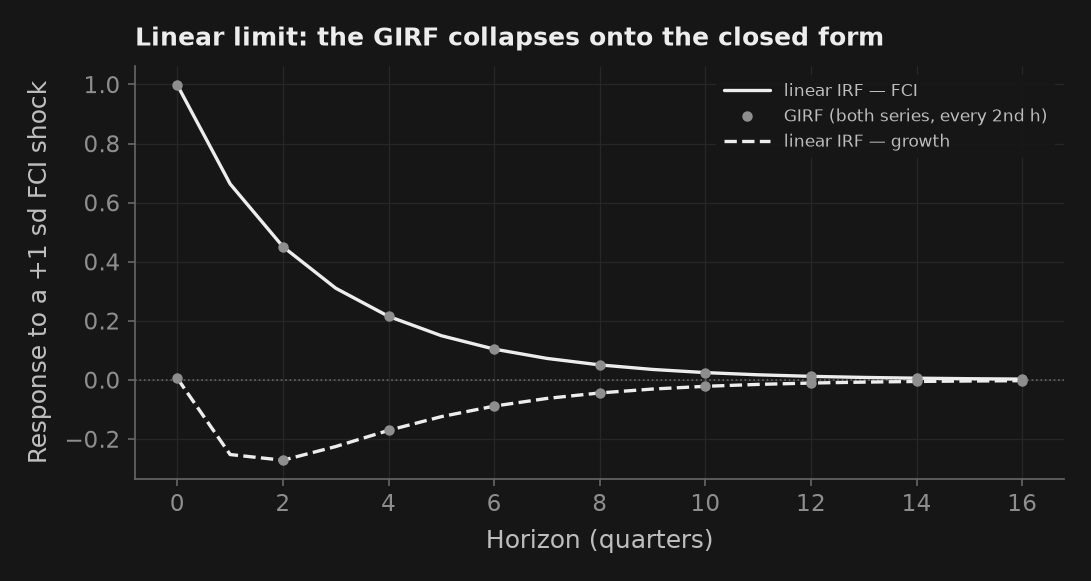

In [5]:
est = estimate_var(Y, 1)
A_hat = np.hstack(est.A_list)
fit_lin = TVARResult(
    A_low=A_hat, intercept_low=est.c, Sigma_low=est.Sigma,
    A_high=A_hat.copy(), intercept_high=est.c.copy(), Sigma_high=est.Sigma.copy(),
    threshold=float(np.median(Y[:, 0])), delay=1, threshold_var_idx=0,
    n_low=0, n_high=0, rss_total=0.0, grid={},
)
chk = girf(fit_lin, Y, shock=0, horizon=16, n_hist=20, n_sim=30, n_boot=100, rng=1)
closed_form = var_irf(est.A_list, np.linalg.cholesky(est.Sigma), 16)[:, :, 0]
gap = np.abs(chk.girf_pooled[0] - closed_form).max()
print(f"max |GIRF - linear IRF| in the linear limit: {gap:.2e}")
print(f"max |regime difference| in the linear limit: {np.abs(chk.difference).max():.2e}")
assert gap < 1e-10
assert np.abs(chk.difference).max() < 1e-12

fig, ax = _nbstyle.figura(ancho=7.0, alto=3.6)
ax.axhline(0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
for j, (name, sty) in enumerate([("FCI", "-"), ("growth", "--")]):
    ax.plot(h, closed_form[:, j], color=_nbstyle.TINTA, linestyle=sty, linewidth=1.6,
            label=f"linear IRF — {name}")
    ax.plot(h[::2], chk.girf_pooled[0, ::2, j], "o", color=_nbstyle.NOTA, markersize=4,
            label="GIRF (both series, every 2nd h)" if j == 0 else None)
ax.set_xlabel("Horizon (quarters)")
ax.set_ylabel("Response to a +1 sd FCI shock")
ax.set_title("Linear limit: the GIRF collapses onto the closed form")
ax.legend(fontsize=8)

**El momento de validación.** Esta es la disciplina que el notebook
quiere que robes: todo estimador basado en simulación debería venir con
un límite en el que su respuesta se conoce *exactamente*. Para la GIRF de
KPP ese límite es "regímenes que no difieren", y la coincidencia de
arriba es a precisión de máquina (del orden de $10^{-16}$, no de
$10^{-2}$). Eso solo es posible porque el impulso se suma al choque
identificado bajo números aleatorios comunes — una decisión de diseño
tomada *para* la testeabilidad. Ten claro qué tipo de oráculo es: ambos
lados son código de `puremacro` (`girf` contra `var.irf`), así que es un
chequeo de consistencia interna del simulador, no evidencia
independiente. Los anclajes independientes de este notebook son el
proceso generador de datos plantado y el MCO simple sobre la partición
verdadera. Cuando el límite lineal se cumple y la asimetría plantada se
recupera con el signo correcto, la banda de diferencias hereda esa
credibilidad — dentro de los límites de lo que la banda mide.

## Tu turno — ¿qué tan grande debe ser un choque para romper la proporcionalidad?

El ejercicio de abajo recalcula la GIRF para un tamaño de choque de tu
elección y la compara, por desviación estándar, contra el punto de
referencia de +1. El impacto es proporcional por construcción, así que
la prueba es la *deriva* en horizontes de ciclo económico: la respuesta
del crecimiento por desviación estándar menos la de +1, promediada sobre
$h = 1,\dots,8$. **Predice su signo antes de correr.** Un choque mayor
que +1 empuja más trayectorias al estrés, donde el arrastre sobre el
crecimiento es cinco veces más fuerte, así que por desviación estándar
debería costar *más* crecimiento (deriva < 0). Un choque menor que +1, o
uno negativo, recluta menos trayectorias de estrés o las saca de él, así
que por desviación estándar debería costar *menos* (deriva > 0). El
`assert` califica esa predicción; se cumple para todo $\delta$ del rango
anunciado y falla cuando el modelo no tiene no linealidad de umbral en
su dinámica.

In [6]:
DELTA_TRY = 2.0   # ← change this: shock size in sd, -5 <= delta <= 5 with |delta - 1| >= 0.5 and delta != 0 (try 0.5, 3.0, -2.0, 5.0)
assert -5.0 <= DELTA_TRY <= 5.0 and abs(DELTA_TRY - 1.0) >= 0.5 and DELTA_TRY != 0.0, \
    "outside the advertised range"
res_try = girf(fit, Y, shock=0, horizon=16, n_hist=30, n_sim=60,
               shock_size=[1.0, DELTA_TRY], n_boot=100, rng=2)
sc_try = res_try.scaled()
drift = sc_try[1, :, 1] - sc_try[0, :, 1]    # per-sd growth response minus the +1 sd benchmark
mean_drift = drift[1:9].mean()              # the first two years after impact
print(f"delta = {DELTA_TRY:+.1f} sd -> mean per-sd growth drift vs +1 sd over h = 1..8: "
      f"{mean_drift:+.4f} (largest |drift| {np.abs(drift).max():.3f} at h = {int(np.abs(drift).argmax())})")
# the prediction: drift has the sign of (1 - delta), and is not zero
assert abs(mean_drift) > 1e-3 and np.sign(mean_drift) == np.sign(1.0 - DELTA_TRY), \
    "prediction failed: explain why"

delta = +2.0 sd -> mean per-sd growth drift vs +1 sd over h = 1..8: -0.0217 (largest |drift| 0.046 at h = 1)


**Ejercicios.** (1) *Básico*: antes de correr, predice el signo de la
deriva para `DELTA_TRY = -2.0` y para `0.5`, y luego corre ambos. ¿Qué
régimen reclutan los choques negativos del ICF, y por qué eso los hace
*más débiles* por desviación estándar? (2) *Intermedio*: fuerza el
rezago equivocado con
`fit_wrong = tvar_fit(Y, threshold_var_idx=0, p=2, delay_grid=(2,), n_threshold_grid=40)`
(un rezago de 2 necesita $p \ge 2$, porque `tvar_fit` descarta $d > p$).
Pasa `fit_wrong` a la GIRF de arriba con los ajustes principales
(`n_hist=40, n_sim=80, n_boot=300, rng=16`) y a la celda del ejercicio.
¿La diferencia estrés-calma en $h=2$ se acerca a cero? ¿Sobrevive la
predicción de signo, y qué dice eso sobre qué conclusiones dependen de
acertar con $d$? (3) *Avanzado*: ajusta
`fit_ms = ms_var_fit(Y, K=2, p=1)` (impórtalo de `puremacro.var.regime`).
Es un MSIH(2)-VAR(1) en la notación de Krolzig (1997): interceptos
$\mu_k$ y covarianzas $\Sigma_k$ propios de cada régimen, una sola $A$
compartida, estimado por EM con el filtro de Hamilton. No es el modelo
de Hamilton (1989), que cambia la media de un proceso AR con varianza
constante. Pasa `fit_ms` a la *misma* `girf` en la celda del ejercicio y
predice, antes de correr, por qué el `assert` falla ahora para todo
$\delta$. Luego verifica que `girf(fit_ms, ...).difference[0]` (régimen
1 menos régimen 0) es igual a
$A^h\big(\mathrm{chol}(\Sigma_1) - \mathrm{chol}(\Sigma_0)\big)e_0$ en
cada horizonte, a partir de `fit_ms.A` y `fit_ms.Sigma`, y que su banda
tiene ancho cero. Los datos se simularon con covarianza identidad en
ambos regímenes: ¿qué está captando esta "diferencia entre regímenes"?
¿Persiste alguno de los regímenes ajustados (mira `fit_ms.P`)? ¿Qué
necesitaría el modelo para generar asimetría de transmisión?

## Por qué esto importa para la investigación de incertidumbre por regímenes

La literatura empírica de incertidumbre por regímenes vive exactamente de
este objeto. Caldara, Fuentes-Albero, Gilchrist y Zakrajšek (2016, *EER*)
sostienen que los choques de incertidumbre se transmiten sobre todo
cuando las condiciones financieras están tensas — una afirmación *sobre*
$\Delta(h)$, contrastable solo con una construcción que deje a la
economía moverse entre estados tensos y holgados a mitad de la respuesta,
como aquí. Del lado estructural, el modelo Diamond-Mortensen-Pissarides
con regímenes de este paquete (`puremacro.models.dmp_regime_dependent`,
`dmp_irf(..., regime="H")` vs `regime="L"`) produce el mismo fenómeno
desde la teoría — regímenes de volatilidad que cambian el cálculo de
excedente de la creación de empleo — y la GIRF es la lente de forma
reducida que apuntarías a datos generados por un modelo así. El flujo de
trabajo honesto que ambos comparten: plantear el modelo de regímenes,
simularlo hacia adelante *con el cambio de régimen intacto*, y reportar
la diferencia entre regímenes con una banda, nunca una IRF de régimen
congelado.

**¿Qué tan exhaustivo es esto?** `girf` despacha sobre los tres ajustes de
regímenes de `puremacro.var.regime` — `tvar_fit` (usado aquí),
`tvecm_fit` (cointegración con umbral, respuestas en niveles) y
`ms_var_fit` (un VAR MSIH con $A$ compartida, ajustado por EM;
trayectorias de régimen extraídas de la matriz de transición ajustada,
así que su GIRF difiere entre regímenes solo a través de
$\mathrm{chol}(\Sigma_k)$). Las alternativas uniecuacionales viven en
`puremacro.lp` (`lp_state_dep` para proyecciones locales dependientes del
estado al estilo Auerbach-Gorodnichenko); `puremacro.uncertainty.regimes`
fecha los regímenes mismos (quiebres de Bai-Perron, regímenes de
calendario); y el notebook 06 cubre las convenciones de identificación
que hereda la elección de Cholesky dentro del régimen.